In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("borismarjanovic/price-volume-data-for-all-us-stocks-etfs")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'price-volume-data-for-all-us-stocks-etfs' dataset.
Path to dataset files: /kaggle/input/price-volume-data-for-all-us-stocks-etfs


In [4]:
import os

print(os.listdir(path))

['Stocks', 'ETFs', 'Data']


In [5]:
import os

stocks_path = os.path.join(path, "Stocks")
etfs_path = os.path.join(path, "ETFs")

print("Stock files:", len(os.listdir(stocks_path)))
print("ETF files:", len(os.listdir(etfs_path)))

Stock files: 7195
ETF files: 1344


In [6]:
import os

stocks_path = os.path.join(path, "Stocks")

stock_files = os.listdir(stocks_path)

# Search for famous companies
for file in stock_files:
    if file.startswith(("aapl", "msft", "tsla", "amzn", "googl")):
        print(file)

aapl.us.txt
tsla.us.txt
msft.us.txt
googl.us.txt
amzn.us.txt


In [7]:
import pandas as pd
import os

file_path = os.path.join(stocks_path, "aapl.us.txt")

df = pd.read_csv(file_path)

df.head()

,Date,Open,High,Low,Close,Volume,OpenInt
0,1984-09-07,0.42388,0.42902,0.41874,0.42388,23220030,0
1,1984-09-10,0.42388,0.42516,0.41366,0.42134,18022532,0
2,1984-09-11,0.42516,0.43668,0.42516,0.42902,42498199,0
3,1984-09-12,0.42902,0.43157,0.41618,0.41618,37125801,0
4,1984-09-13,0.43927,0.44052,0.43927,0.43927,57822062,0


In [8]:
data = df[['Close']]

data.head()

,Close
0,0.42388
1,0.42134
2,0.42902
3,0.41618
4,0.43927


In [9]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

In [10]:
import numpy as np

X = []
y = []

window = 60

for i in range(window, len(scaled_data)):
    X.append(scaled_data[i-window:i])
    y.append(scaled_data[i])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(8304, 60, 1)
(8304, 1)


In [11]:
train_size = int(len(X)*0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print(X_train.shape)
print(X_test.shape)

(6643, 60, 1)
(1661, 60, 1)


In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


model = Sequential([

    LSTM(64, return_sequences=True,
         input_shape=(60,1)),

    Dropout(0.2),

    LSTM(32),

    Dense(1)
])


model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)


model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test,y_test)
)

Epoch 1/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step - loss: 8.5064e-05 - val_loss: 0.0014
Epoch 2/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 12s 57ms/step - loss: 1.5027e-05 - val_loss: 4.8829e-04
Epoch 3/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 19s 51ms/step - loss: 1.4543e-05 - val_loss: 7.7684e-04
Epoch 4/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step - loss: 1.3803e-05 - val_loss: 7.0542e-04
Epoch 5/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 12s 58ms/step - loss: 1.2228e-05 - val_loss: 8.0964e-04
Epoch 6/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 11s 55ms/step - loss: 1.2147e-05 - val_loss: 8.6696e-04
Epoch 7/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - loss: 1.2147e-05 - val_loss: 6.6337e-04
Epoch 8/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 19s 50ms/step - loss: 1.0060e-05 - val_loss: 2.9168e-04
Epoch 9/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 11s 53ms/step - loss: 1.0919e-05 - val_loss: 2.9836e-04
Epoch 10/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 12s 57ms/step - loss: 1.0952e-05 - val_loss: 0.0014
Epoch 11/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 12s 58

In [14]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Dropout

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

In [15]:
def build_rnn():

    model = Sequential([

        SimpleRNN(
            64,
            return_sequences=True,
            input_shape=(60,1)
        ),

        Dropout(0.2),

        SimpleRNN(32),

        Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    return model

In [16]:
def build_lstm():

    model = Sequential([

        LSTM(
            64,
            return_sequences=True,
            input_shape=(60,1)
        ),

        Dropout(0.2),

        LSTM(32),

        Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    return model

In [17]:
def build_gru():

    model = Sequential([

        GRU(
            64,
            return_sequences=True,
            input_shape=(60,1)
        ),

        Dropout(0.2),

        GRU(32),

        Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    return model

In [18]:
models = {
    "RNN": build_rnn(),
    "LSTM": build_lstm(),
    "GRU": build_gru()
}


history = {}

for name, model in models.items():

    print("\nTraining", name)

    history[name] = model.fit(
        X_train,
        y_train,
        epochs=50,
        batch_size=32,
        validation_data=(X_test,y_test),
        verbose=1
    )


Training RNN
Epoch 1/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - loss: 0.0028 - val_loss: 0.0478
Epoch 2/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 2.1367e-04 - val_loss: 0.0234
Epoch 3/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 1.4728e-04 - val_loss: 0.0113
Epoch 4/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 8.9823e-05 - val_loss: 0.0125
Epoch 5/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - loss: 7.1915e-05 - val_loss: 0.0096
Epoch 6/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - loss: 7.0941e-05 - val_loss: 0.0069
Epoch 7/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 5.5798e-05 - val_loss: 0.0053
Epoch 8/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 3.6765e-05 - val_loss: 0.0030
Epoch 9/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 3.7902e-05 - val_loss: 0.0036
Epoch 10/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - loss: 3.3032e-05 - val_loss: 0.0051
Epoch 11/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 3.5506e-05 - val_

In [19]:
results = {}

for name, model in models.items():

    prediction = model.predict(X_test)

    prediction = scaler.inverse_transform(prediction)
    actual = scaler.inverse_transform(y_test)


    rmse = np.sqrt(
        mean_squared_error(actual,prediction)
    )

    mae = mean_absolute_error(
        actual,prediction
    )

    mape = np.mean(
        np.abs((actual-prediction)/actual)
    ) * 100


    r2 = r2_score(
        actual,
        prediction
    )


    results[name] = [
        rmse,
        mae,
        mape,
        r2
    ]


comparison = pd.DataFrame(
    results,
    index=[
        "RMSE",
        "MAE",
        "MAPE %",
        "R2"
    ]
).T


comparison

52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


,RMSE,MAE,MAPE %,R2
RNN,6.318708,4.058166,4.141765,0.958911
LSTM,4.933943,2.920343,2.688067,0.974947
GRU,3.702000,2.571573,2.483517,0.985896


52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


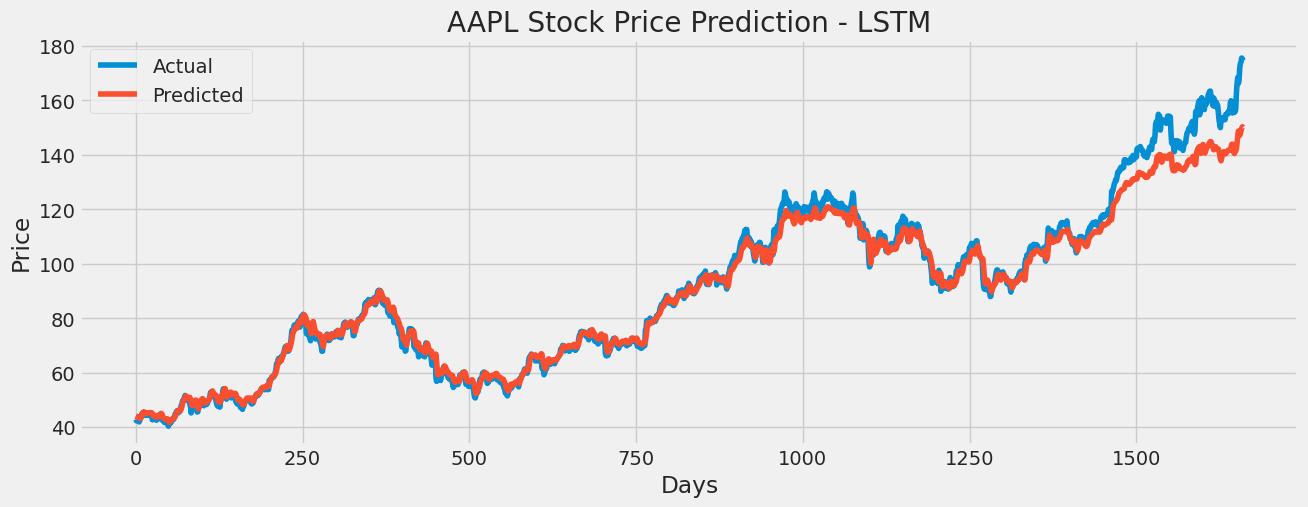

In [20]:
best_model = models["LSTM"]

pred = best_model.predict(X_test)

pred = scaler.inverse_transform(pred)
actual = scaler.inverse_transform(y_test)


plt.figure(figsize=(14,5))

plt.plot(actual, label="Actual")
plt.plot(pred, label="Predicted")

plt.title("AAPL Stock Price Prediction - LSTM")
plt.xlabel("Days")
plt.ylabel("Price")

plt.legend()
plt.grid(True)
plt.show()